In [1]:
import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [3]:

PROJECT_DIR = Path.cwd()

# output folders
PROCESSED_DIR = PROJECT_DIR / "data_processed"
FIG_DIR = PROJECT_DIR / "figures"

PROCESSED_DIR.mkdir(exist_ok=True)
FIG_DIR.mkdir(exist_ok=True)

# change only this line if your file name is different
CRASH_CSV = PROJECT_DIR / "Traffic_Crashes_-_Crashes.csv"

print("Project folder:", PROJECT_DIR)
print("CSV path:", CRASH_CSV)
print("CSV exists:", CRASH_CSV.exists())

Project folder: /Users/aanchal
CSV path: /Users/aanchal/Traffic_Crashes_-_Crashes.csv
CSV exists: True


In [5]:
# load full crash dataset
df = pd.read_csv(CRASH_CSV)

print("Shape:", df.shape)
print("\nFirst 10 columns:")
print(df.columns[:10].tolist())

print("\nAll columns:")
print(df.columns.tolist())

Shape: (53608, 48)

First 10 columns:
['CRASH_RECORD_ID', 'CRASH_DATE_EST_I', 'CRASH_DATE', 'POSTED_SPEED_LIMIT', 'TRAFFIC_CONTROL_DEVICE', 'DEVICE_CONDITION', 'WEATHER_CONDITION', 'LIGHTING_CONDITION', 'FIRST_CRASH_TYPE', 'TRAFFICWAY_TYPE']

All columns:
['CRASH_RECORD_ID', 'CRASH_DATE_EST_I', 'CRASH_DATE', 'POSTED_SPEED_LIMIT', 'TRAFFIC_CONTROL_DEVICE', 'DEVICE_CONDITION', 'WEATHER_CONDITION', 'LIGHTING_CONDITION', 'FIRST_CRASH_TYPE', 'TRAFFICWAY_TYPE', 'LANE_CNT', 'ALIGNMENT', 'ROADWAY_SURFACE_COND', 'ROAD_DEFECT', 'REPORT_TYPE', 'CRASH_TYPE', 'INTERSECTION_RELATED_I', 'NOT_RIGHT_OF_WAY_I', 'HIT_AND_RUN_I', 'DAMAGE', 'DATE_POLICE_NOTIFIED', 'PRIM_CONTRIBUTORY_CAUSE', 'SEC_CONTRIBUTORY_CAUSE', 'STREET_NO', 'STREET_DIRECTION', 'STREET_NAME', 'BEAT_OF_OCCURRENCE', 'PHOTOS_TAKEN_I', 'STATEMENTS_TAKEN_I', 'DOORING_I', 'WORK_ZONE_I', 'WORK_ZONE_TYPE', 'WORKERS_PRESENT_I', 'NUM_UNITS', 'MOST_SEVERE_INJURY', 'INJURIES_TOTAL', 'INJURIES_FATAL', 'INJURIES_INCAPACITATING', 'INJURIES_NON_INCAPA

In [7]:
# keep only columns relevant to this project for profiling and later integration
selected_cols = [
    "CRASH_RECORD_ID",
    "CRASH_DATE",
    "WEATHER_CONDITION",
    "ROADWAY_SURFACE_COND",
    "LIGHTING_CONDITION",
    "MOST_SEVERE_INJURY",
    "INJURIES_TOTAL",
    "INJURIES_FATAL",
    "INJURIES_INCAPACITATING",
    "INJURIES_NON_INCAPACITATING",
    "INJURIES_REPORTED_NOT_EVIDENT",
    "INJURIES_NO_INDICATION",
    "INJURIES_UNKNOWN",
    "LATITUDE",
    "LONGITUDE",
    "LOCATION"
]

crash = df[selected_cols].copy()

print("Selected shape:", crash.shape)
crash.head()

Selected shape: (53608, 16)


,CRASH_RECORD_ID,CRASH_DATE,WEATHER_CONDITION,ROADWAY_SURFACE_COND,LIGHTING_CONDITION,MOST_SEVERE_INJURY,INJURIES_TOTAL,INJURIES_FATAL,INJURIES_INCAPACITATING,INJURIES_NON_INCAPACITATING,INJURIES_REPORTED_NOT_EVIDENT,INJURIES_NO_INDICATION,INJURIES_UNKNOWN,LATITUDE,LONGITUDE,LOCATION
0,257543e5ef74486a879ea737ea8b061184876be2a1657d...,06/30/2025 06:42:00 PM,CLEAR,DRY,DAYLIGHT,NO INDICATION OF INJURY,0.0,0.0,0.0,0.0,0.0,2.0,0.0,41.938758,-87.743920,POINT (-87.743920312025 41.93875847344)
1,185eff0298ff3ae91a8b84601bbe0abb643b245ba65d7a...,06/30/2025 06:40:00 PM,CLEAR,DRY,DAYLIGHT,NO INDICATION OF INJURY,0.0,0.0,0.0,0.0,0.0,1.0,0.0,41.882062,-87.633094,POINT (-87.633094020564 41.882061673458)
2,28a5528bb10449b61937bca3105c8b86942090a96caf67...,06/30/2025 06:40:00 PM,CLEAR,DRY,DUSK,NO INDICATION OF INJURY,0.0,0.0,0.0,0.0,0.0,3.0,0.0,41.961422,-87.688747,POINT (-87.688746979839 41.961421726406)
3,382dd0dc9db63ef32f5a6383a753ef1dab04733630b0b2...,06/30/2025 06:40:00 PM,CLEAR,DRY,DAYLIGHT,NONINCAPACITATING INJURY,1.0,0.0,0.0,1.0,0.0,1.0,0.0,41.866752,-87.666265,POINT (-87.66626468919 41.86675185614)
4,fe7efd38c25fe4471e5907bf6883aebde2a9c26a030871...,06/30/2025 06:35:00 PM,CLEAR,DRY,DAYLIGHT,NONINCAPACITATING INJURY,1.0,0.0,0.0,1.0,0.0,1.0,0.0,41.843981,-87.708823,POINT (-87.708822778662 41.843980568711)


In [13]:
crash["CRASH_DATE"] = pd.to_datetime(
    crash["CRASH_DATE"],
    format="%m/%d/%Y %I:%M:%S %p",
    errors="coerce"
)

crash["crash_day"] = pd.to_datetime(crash["CRASH_DATE"].dt.date)

crash[["CRASH_DATE", "crash_day"]].head()

,CRASH_DATE,crash_day
0,2025-06-30 18:42:00,2025-06-30
1,2025-06-30 18:40:00,2025-06-30
2,2025-06-30 18:40:00,2025-06-30
3,2025-06-30 18:40:00,2025-06-30
4,2025-06-30 18:35:00,2025-06-30


In [15]:
basic_summary = pd.DataFrame({
    "metric": [
        "row_count",
        "column_count",
        "min_crash_date",
        "max_crash_date",
        "missing_crash_record_id",
        "duplicate_crash_record_id",
        "missing_crash_date",
        "unique_crash_days"
    ],
    "value": [
        crash.shape[0],
        crash.shape[1],
        crash["CRASH_DATE"].min(),
        crash["CRASH_DATE"].max(),
        crash["CRASH_RECORD_ID"].isna().sum(),
        crash["CRASH_RECORD_ID"].duplicated().sum(),
        crash["CRASH_DATE"].isna().sum(),
        crash["crash_day"].nunique()
    ]
})

basic_summary

,metric,value
0,row_count,53608
1,column_count,17
2,min_crash_date,2025-01-01 19:15:00
3,max_crash_date,2025-06-30 18:42:00
4,missing_crash_record_id,0
5,duplicate_crash_record_id,0
6,missing_crash_date,0
7,unique_crash_days,181


In [17]:
crash.to_csv(PROCESSED_DIR / "crash_selected_columns.csv", index=False)
basic_summary.to_csv(PROCESSED_DIR / "crash_basic_summary.csv", index=False)

print("Saved:")
print(PROCESSED_DIR / "crash_selected_columns.csv")
print(PROCESSED_DIR / "crash_basic_summary.csv")

Saved:
/Users/aanchal/data_processed/crash_selected_columns.csv
/Users/aanchal/data_processed/crash_basic_summary.csv


In [19]:
missingness = pd.DataFrame({
    "column": crash.columns,
    "missing_count": crash.isna().sum().values,
    "missing_pct": (crash.isna().mean().values * 100).round(2)
}).sort_values(["missing_pct", "missing_count"], ascending=False)

missingness

,column,missing_count,missing_pct
13,LATITUDE,580,1.08
14,LONGITUDE,580,1.08
15,LOCATION,580,1.08
5,MOST_SEVERE_INJURY,107,0.20
6,INJURIES_TOTAL,107,0.20
7,INJURIES_FATAL,107,0.20
8,INJURIES_INCAPACITATING,107,0.20
9,INJURIES_NON_INCAPACITATING,107,0.20
10,INJURIES_REPORTED_NOT_EVIDENT,107,0.20
11,INJURIES_NO_INDICATION,107,0.20


In [21]:
missingness.to_csv(PROCESSED_DIR / "missingness_summary.csv", index=False)
print(PROCESSED_DIR / "missingness_summary.csv")

/Users/aanchal/data_processed/missingness_summary.csv


In [23]:
def value_counts_df(series, colname):
    out = (
        series.fillna("<<MISSING>>")
        .astype(str)
        .str.strip()
        .value_counts(dropna=False)
        .rename_axis(colname)
        .reset_index(name="count")
    )
    out["pct"] = (out["count"] / out["count"].sum() * 100).round(2)
    return out

In [25]:
weather_counts = value_counts_df(crash["WEATHER_CONDITION"], "WEATHER_CONDITION")
surface_counts = value_counts_df(crash["ROADWAY_SURFACE_COND"], "ROADWAY_SURFACE_COND")
lighting_counts = value_counts_df(crash["LIGHTING_CONDITION"], "LIGHTING_CONDITION")
severity_counts = value_counts_df(crash["MOST_SEVERE_INJURY"], "MOST_SEVERE_INJURY")

weather_counts.head(15)

,WEATHER_CONDITION,count,pct
0,CLEAR,41323,77.08
1,UNKNOWN,4241,7.91
2,RAIN,3727,6.95
3,SNOW,1717,3.20
4,CLOUDY/OVERCAST,1650,3.08
5,FREEZING RAIN/DRIZZLE,506,0.94
6,OTHER,267,0.50
7,SLEET/HAIL,87,0.16
8,FOG/SMOKE/HAZE,40,0.07
9,BLOWING SNOW,30,0.06


In [27]:
surface_counts.head(15)

,ROADWAY_SURFACE_COND,count,pct
0,DRY,37439,69.84
1,UNKNOWN,7632,14.24
2,WET,5862,10.93
3,SNOW OR SLUSH,1537,2.87
4,ICE,936,1.75
5,OTHER,184,0.34
6,"SAND, MUD, DIRT",18,0.03


In [29]:
weather_counts.to_csv(PROCESSED_DIR / "category_counts_weather.csv", index=False)
surface_counts.to_csv(PROCESSED_DIR / "category_counts_surface.csv", index=False)
lighting_counts.to_csv(PROCESSED_DIR / "category_counts_lighting.csv", index=False)
severity_counts.to_csv(PROCESSED_DIR / "category_counts_severity.csv", index=False)

print("Saved category count files.")

Saved category count files.


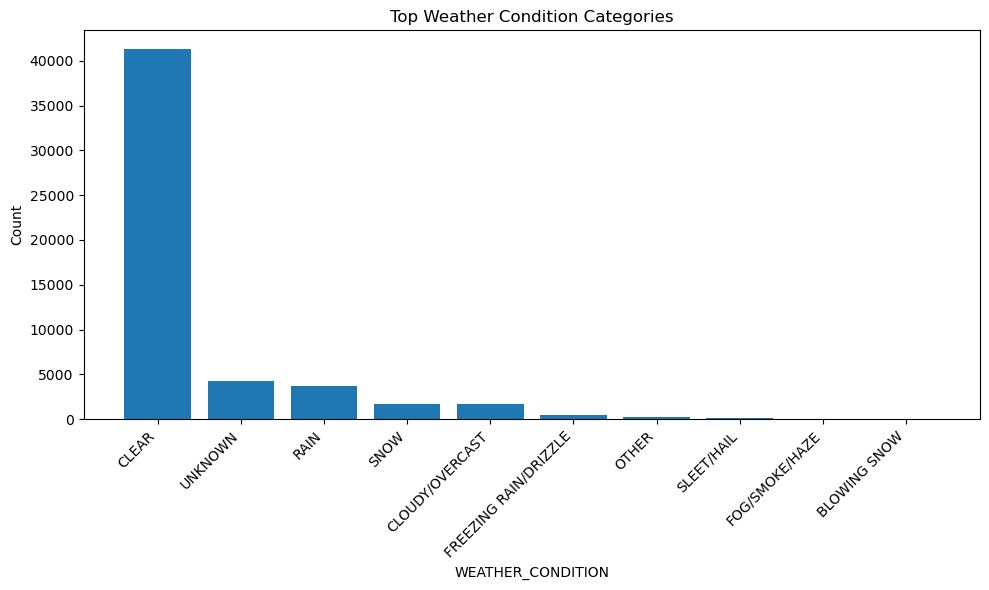

In [31]:
top_weather = weather_counts.head(10)

plt.figure(figsize=(10, 6))
plt.bar(top_weather["WEATHER_CONDITION"], top_weather["count"])
plt.xticks(rotation=45, ha="right")
plt.title("Top Weather Condition Categories")
plt.xlabel("WEATHER_CONDITION")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig(FIG_DIR / "weather_condition_counts.png", dpi=200)
plt.show()

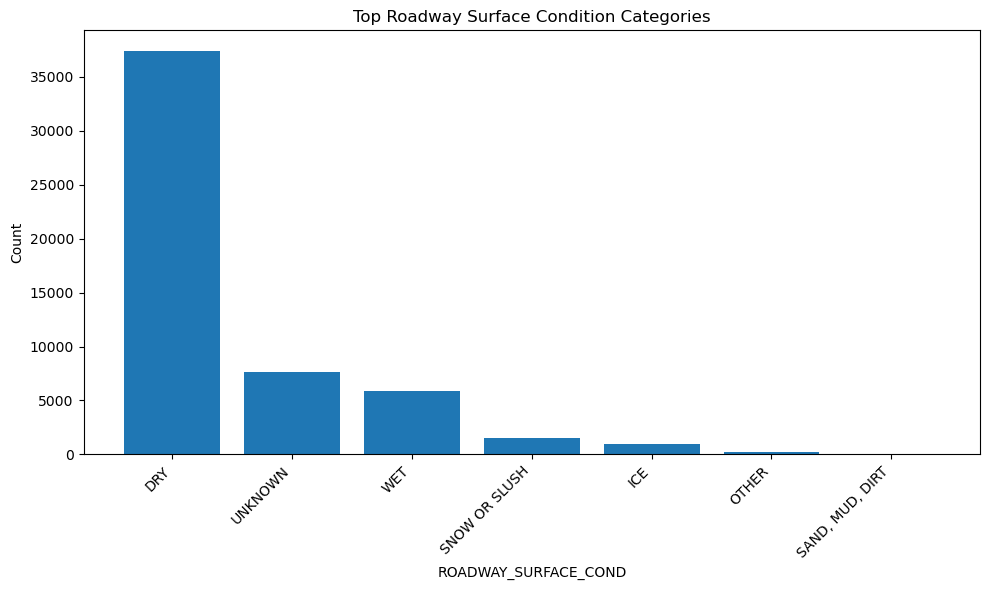

In [33]:
top_surface = surface_counts.head(10)

plt.figure(figsize=(10, 6))
plt.bar(top_surface["ROADWAY_SURFACE_COND"], top_surface["count"])
plt.xticks(rotation=45, ha="right")
plt.title("Top Roadway Surface Condition Categories")
plt.xlabel("ROADWAY_SURFACE_COND")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig(FIG_DIR / "roadway_surface_counts.png", dpi=200)
plt.show()

In [35]:
injury_cols = [
    "INJURIES_TOTAL",
    "INJURIES_FATAL",
    "INJURIES_INCAPACITATING",
    "INJURIES_NON_INCAPACITATING",
    "INJURIES_REPORTED_NOT_EVIDENT",
    "INJURIES_NO_INDICATION",
    "INJURIES_UNKNOWN"
]

for col in injury_cols:
    crash[col] = pd.to_numeric(crash[col], errors="coerce")

crash["weather_unknown_flag"] = crash["WEATHER_CONDITION"].astype(str).str.strip().isin(["UNKNOWN", "OTHER"]).astype(int)
crash["surface_unknown_flag"] = crash["ROADWAY_SURFACE_COND"].astype(str).str.strip().isin(["UNKNOWN", "OTHER"]).astype(int)

In [37]:
daily = (
    crash.groupby("crash_day", dropna=False)
    .agg(
        daily_crash_count=("CRASH_RECORD_ID", "count"),
        daily_injuries_total=("INJURIES_TOTAL", "sum"),
        daily_injuries_fatal=("INJURIES_FATAL", "sum"),
        daily_injuries_incapacitating=("INJURIES_INCAPACITATING", "sum"),
        daily_unknown_weather_count=("weather_unknown_flag", "sum"),
        daily_unknown_surface_count=("surface_unknown_flag", "sum")
    )
    .reset_index()
    .sort_values("crash_day")
)

daily.head()

,crash_day,daily_crash_count,daily_injuries_total,daily_injuries_fatal,daily_injuries_incapacitating,daily_unknown_weather_count,daily_unknown_surface_count
0,2025-01-01,26,5.0,0.0,1.0,0,4
1,2025-01-02,188,46.0,0.0,1.0,27,28
2,2025-01-03,209,33.0,0.0,2.0,23,39
3,2025-01-04,207,37.0,0.0,3.0,24,35
4,2025-01-05,186,31.0,1.0,3.0,14,25


In [39]:
daily.to_csv(PROCESSED_DIR / "crash_daily_aggregated.csv", index=False)
print(PROCESSED_DIR / "crash_daily_aggregated.csv")

/Users/aanchal/data_processed/crash_daily_aggregated.csv


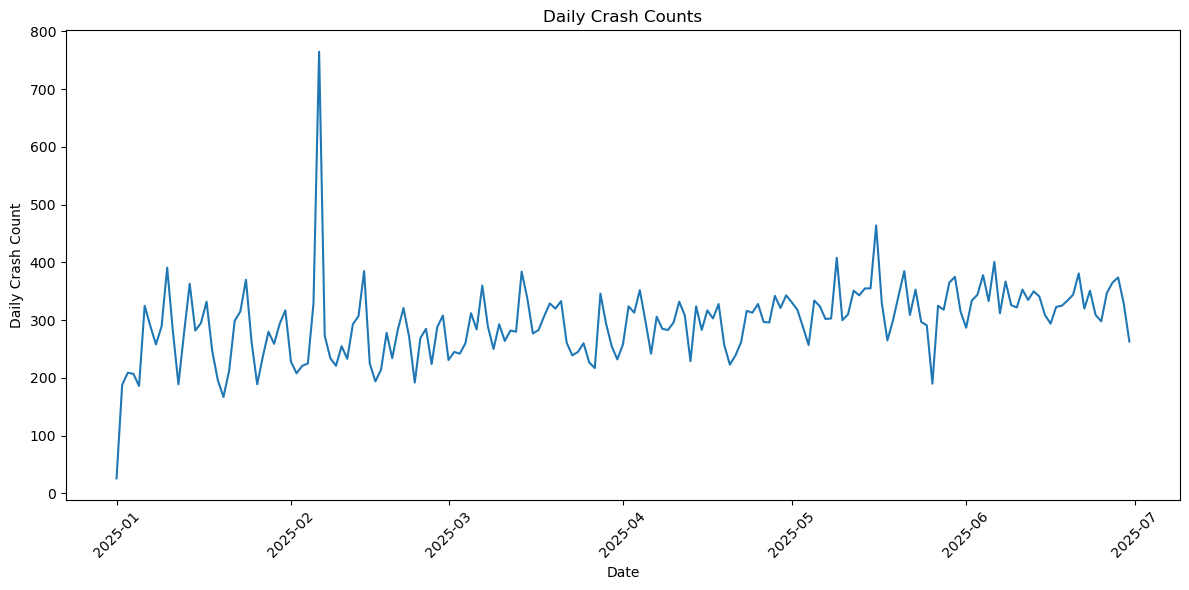

In [41]:
plt.figure(figsize=(12, 6))
plt.plot(daily["crash_day"], daily["daily_crash_count"])
plt.title("Daily Crash Counts")
plt.xlabel("Date")
plt.ylabel("Daily Crash Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(FIG_DIR / "daily_crash_counts.png", dpi=200)
plt.show()

In [43]:
check_df = crash.copy()

for col in ["WEATHER_CONDITION", "ROADWAY_SURFACE_COND", "LIGHTING_CONDITION", "MOST_SEVERE_INJURY"]:
    check_df[col] = check_df[col].astype(str).str.strip()

check_A = check_df[
    (check_df["WEATHER_CONDITION"] == "CLEAR") &
    (check_df["ROADWAY_SURFACE_COND"].isin(["WET", "SNOW OR SLUSH", "ICE"]))
].copy()

snow_like = ["SNOW", "FREEZING RAIN/DRIZZLE", "SLEET/HAIL", "BLOWING SNOW"]
check_B = check_df[
    (check_df["WEATHER_CONDITION"].isin(snow_like)) &
    (check_df["ROADWAY_SURFACE_COND"] == "DRY")
].copy()

check_C = check_df[
    (check_df["WEATHER_CONDITION"].isin(["UNKNOWN", "OTHER"])) &
    (~check_df["ROADWAY_SURFACE_COND"].isin(["UNKNOWN", "OTHER", "nan"]))
].copy()

issue_summary = pd.DataFrame({
    "check_name": [
        "CLEAR weather with WET/SNOW OR SLUSH/ICE roadway",
        "SNOW/FREEZING weather with DRY roadway",
        "UNKNOWN/OTHER weather with known roadway surface"
    ],
    "row_count": [len(check_A), len(check_B), len(check_C)]
})

issue_summary

,check_name,row_count
0,CLEAR weather with WET/SNOW OR SLUSH/ICE roadway,1974
1,SNOW/FREEZING weather with DRY roadway,57
2,UNKNOWN/OTHER weather with known roadway surface,479


In [45]:
check_A.to_csv(PROCESSED_DIR / "check_A_clear_vs_surface.csv", index=False)
check_B.to_csv(PROCESSED_DIR / "check_B_snow_vs_dry.csv", index=False)
check_C.to_csv(PROCESSED_DIR / "check_C_unknown_weather_known_surface.csv", index=False)
issue_summary.to_csv(PROCESSED_DIR / "issue_check_summary.csv", index=False)

print("Saved issue check outputs.")

Saved issue check outputs.


In [47]:
weather_unknown_other = crash["WEATHER_CONDITION"].astype(str).str.strip().isin(["UNKNOWN", "OTHER"]).sum()
surface_unknown_other = crash["ROADWAY_SURFACE_COND"].astype(str).str.strip().isin(["UNKNOWN", "OTHER"]).sum()

quick_stats = pd.DataFrame({
    "metric": [
        "weather_unknown_other_count",
        "weather_unknown_other_pct",
        "surface_unknown_other_count",
        "surface_unknown_other_pct"
    ],
    "value": [
        int(weather_unknown_other),
        round(weather_unknown_other / len(crash) * 100, 2),
        int(surface_unknown_other),
        round(surface_unknown_other / len(crash) * 100, 2)
    ]
})

quick_stats

,metric,value
0,weather_unknown_other_count,4508.00
1,weather_unknown_other_pct,8.41
2,surface_unknown_other_count,7816.00
3,surface_unknown_other_pct,14.58
